# Integrated Climate-Macroeconomics — The DICE Model and Carbon Pricing

**How do economic growth, greenhouse gas emissions, and global climate feedback interact over century-long horizons, and what is the optimal path for the Social Cost of Carbon?**

Over the coming century, macroeconomic aggregates and climate dynamics will be inextricably coupled. Fossil fuel combustion drives global anthropogenic greenhouse gas emissions, which accumulate in atmospheric reservoirs, amplify radiative forcing, and elevate mean surface temperatures. Rising temperatures, in turn, trigger severe macroeconomic damages: depressed agricultural yields, accelerated capital depreciation from extreme weather events, lower labor productivity in hot regions, and biodiversity collapse.

To analyze this multi-century biophysical and economic feedback loop, William Nordhaus (2018 Nobel Laureate in Economics) pioneered the **Dynamic Integrated Climate-Economy (DICE)** model. In DICE, an optimizing global Ramsey planner balances the intertemporal trade-off between current consumption, capital accumulation, and emission abatement:
1. **Mitigation Costs**: Cutting greenhouse gas emissions requires deploying low-carbon technologies, replacing fossil capital, and improving energy efficiency, which diverts resources from current consumption and investment.
2. **Avoided Climate Damages**: Abating emissions reduces the long-run atmospheric carbon concentration, dampening warming and preserving future productive capacity.

Modern extensions (Golosov, Hassler, Krusell & Tsyvinski 2014, *Econometrica*; Nordhaus 2017, *PNAS*) formalize the concept of the **Social Cost of Carbon (SCC)**: the present discounted value of all future marginal damages to global gross output caused by an additional metric ton of $\text{CO}_2$ emitted today. The SCC provides the theoretically rigorous Pigouvian price that should be placed on carbon emissions through taxes or cap-and-trade allowances.

In this interactive showcase, we simulate the DICE-2016R model across a 150-year horizon (2020–2170) using `puremacro.climate.simulate_dice_model`, comparing a moderate baseline trajectory against an accelerated carbon tax schedule designed to satisfy international climate guardrails.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.climate import simulate_dice_model

## 1. Simulating Baseline vs. Accelerated Carbon Tax Policies

The geophysical and economic architecture of the DICE model is structured into four interconnected modules:

1. **Global Production & Gross Output**:
   Gross world product $Y_{gross, t}$ follows an aggregate Cobb-Douglas technology over capital $K_t$ and labor $L_t$, augmented by exogenous total factor productivity $A_t$:
   $$ Y_{gross, t} = A_t K_t^\gamma L_t^{1-\gamma} $$
2. **Carbon Cycle Dynamics (Three-Reservoir System)**:
   Emissions $E_t = \sigma_t (1 - \mu_t) Y_{gross, t} + E_{land, t}$ flow into the atmosphere, where $\sigma_t$ is the carbon intensity of output and $\mu_t \in [0, 1]$ is the emissions control rate. The carbon stock vector $\mathbf{M}_t = (M_{AT, t}, M_{UP, t}, M_{LO, t})^\top$ evolves via linear transition matrix $\mathbf{\Phi}_M$:
   $$ \mathbf{M}_{t+1} = \mathbf{\Phi}_M \mathbf{M}_t + \begin{pmatrix} E_t \\ 0 \\ 0 \end{pmatrix} $$
3. **Radiative Forcing & Two-Layer Thermal Ocean**:
   Atmospheric carbon concentration translates into radiative forcing $F_t = \eta \log_2 \left( \frac{M_{AT, t}}{M_{AT, pre}} \right) + F_{EX, t}$, which drives surface atmospheric temperature $T_{AT, t}$ and deep ocean temperature $T_{LO, t}$.
4. **Net Output with Abatement Costs and Climate Damages**:
   Net output available for consumption and investment is:
   $$ Y_{net, t} = \left[ 1 - \Lambda_t(\mu_t) \right] \left[ 1 - \Omega(T_{AT, t}) \right] Y_{gross, t} $$
   where the Nordhaus quadratic damage fraction is $\Omega(T_t) = \frac{\pi_1 T_t + \pi_2 T_t^2}{1 + \pi_1 T_t + \pi_2 T_t^2}$ and the abatement cost function is $\Lambda_t(\mu_t) = \theta_{1, t} \mu_t^{\theta_2}$.

Below, we simulate:
- **Baseline**: Initial carbon tax of $\$40/\text{tCO}_2$ growing at $2.0\%$ per year.
- **Accelerated Policy**: Ambitious initial tax of $\$80/\text{tCO}_2$ growing at $3.5\%$ per year.

In [2]:
res_base = simulate_dice_model(
    n_periods=30,
    time_step_years=5,
    start_year=2020,
    carbon_tax_initial=40.0,
    carbon_tax_growth=0.02,
)
print("=== Baseline Scenario ===")
print(res_base.summary())

res_policy = simulate_dice_model(
    n_periods=30,
    time_step_years=5,
    start_year=2020,
    carbon_tax_initial=80.0,
    carbon_tax_growth=0.035,
)
print("\n=== Accelerated Carbon Tax Scenario ===")
print(res_policy.summary())

=== Baseline Scenario ===
DICE-2016R forward simulation (Nordhaus 2017)
Horizon                         : 30 periods of 5 years, 2020-2165
Initial Social Cost of Carbon   : $34.71 / tCO2  (rho = 0.015, eta = 1.45)
Peak Global Surface Warming     : 4.13 degC above pre-industrial
End-Century (2100) Damage Share : 2.66% of gross output
------------------------------------------------------------------------
Key Benchmark Years (nearest available row):
  Year 2025: Temp +1.27degC | Emissions 33.7 GtCO2/yr | Damage 0.38% | Tax $44.2/t | SCC $39.8/t
  Year 2050: Temp +1.96degC | Emissions 38.3 GtCO2/yr | Damage 0.91% | Tax $72.5/t | SCC $78.7/t
  Year 2075: Temp +2.69degC | Emissions 35.5 GtCO2/yr | Damage 1.71% | Tax $118.9/t | SCC $142.0/t
  Year 2100: Temp +3.36degC | Emissions 23.1 GtCO2/yr | Damage 2.66% | Tax $195.0/t | SCC $233.3/t

=== Accelerated Carbon Tax Scenario ===
DICE-2016R forward simulation (Nordhaus 2017)
Horizon                         : 30 periods of 5 years, 2020-2165
I

## 2. Surface Warming Anomalies & Paris Agreement Guardrails

Under the 2015 Paris Agreement, international policymakers pledged to hold the increase in global average temperature well below $2.0^\circ\text{C}$ above pre-industrial levels and pursue efforts to limit warming to $1.5^\circ\text{C}$.

In the Baseline Scenario ($\$40/\text{tCO}_2$ growing at $2\%$), mitigation is insufficient to prevent dangerous climate change: global surface temperature breaches the $1.5^\circ\text{C}$ threshold by 2040, crosses the $2.0^\circ\text{C}$ guardrail before 2060, and reaches $+3.36^\circ\text{C}$ by 2100, continuing toward $+4.1^\circ\text{C}$ in the 22nd century.

In contrast, the Accelerated Carbon Tax Scenario bends the emissions trajectory rapidly: warming peaks near $2.1^\circ\text{C}$ around 2085 before stabilizing, substantially mitigating irreversible planetary tipping risks.

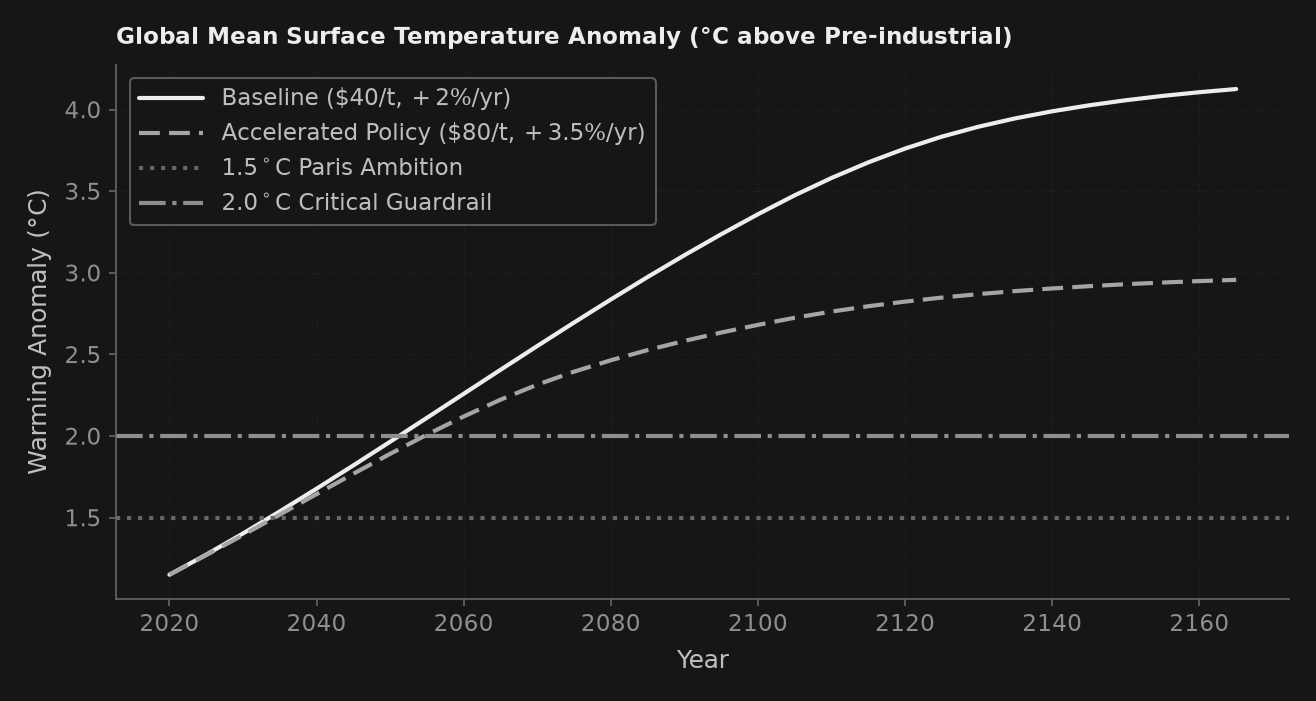

In [3]:
fig, ax = _nbstyle.figura(figsize=(8.5, 4.4))
ax.plot(res_base.trajectories.index, res_base.trajectories["temperature_anomaly"], **_nbstyle.S1, label=r"Baseline ($\$40/\mathrm{t}, +2\%/\mathrm{yr}$)")
ax.plot(res_policy.trajectories.index, res_policy.trajectories["temperature_anomaly"], **_nbstyle.S2, label=r"Accelerated Policy ($\$80/\mathrm{t}, +3.5\%/\mathrm{yr}$)")
ax.axhline(1.5, color=_nbstyle.SPINE, linestyle=":", label=r"$1.5^\circ\mathrm{C}$ Paris Ambition")
ax.axhline(2.0, color=_nbstyle.NOTA, linestyle="-.", label=r"$2.0^\circ\mathrm{C}$ Critical Guardrail")
ax.set_title("Global Mean Surface Temperature Anomaly (°C above Pre-industrial)", fontsize=11, fontweight="bold")
ax.set_xlabel("Year", color=_nbstyle.TEXTO)
ax.set_ylabel("Warming Anomaly (°C)", color=_nbstyle.TEXTO)
ax.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

## 3. Global CO2 Emissions and Decarbonization Paths

The decarbonization schedule illustrates the direct impact of carbon pricing on industrial emissions. The emissions control rate $\mu_t$ responds endogenously to the carbon tax $\tau_t$ by equating the marginal abatement cost to the tax rate:

$$ \text{MAC}_t(\mu_t) = \frac{\partial \Lambda_t}{\partial \mu_t} \cdot \frac{Y_{gross, t}}{\sigma_t Y_{gross, t}} = \frac{\theta_{1, t} \theta_2 \mu_t^{\theta_2 - 1}}{\sigma_t} = \tau_t $$

In the Baseline case, emissions remain above $30\,\text{GtCO}_2/\text{year}$ through 2080 as economic growth offsets weak abatement. In the Accelerated Policy scenario, annual global emissions peak almost immediately (around 2025 at $32\,\text{GtCO}_2/\text{year}$) and collapse toward net-zero by the final decades of the century, establishing a structural decoupling between economic growth and carbon emissions.

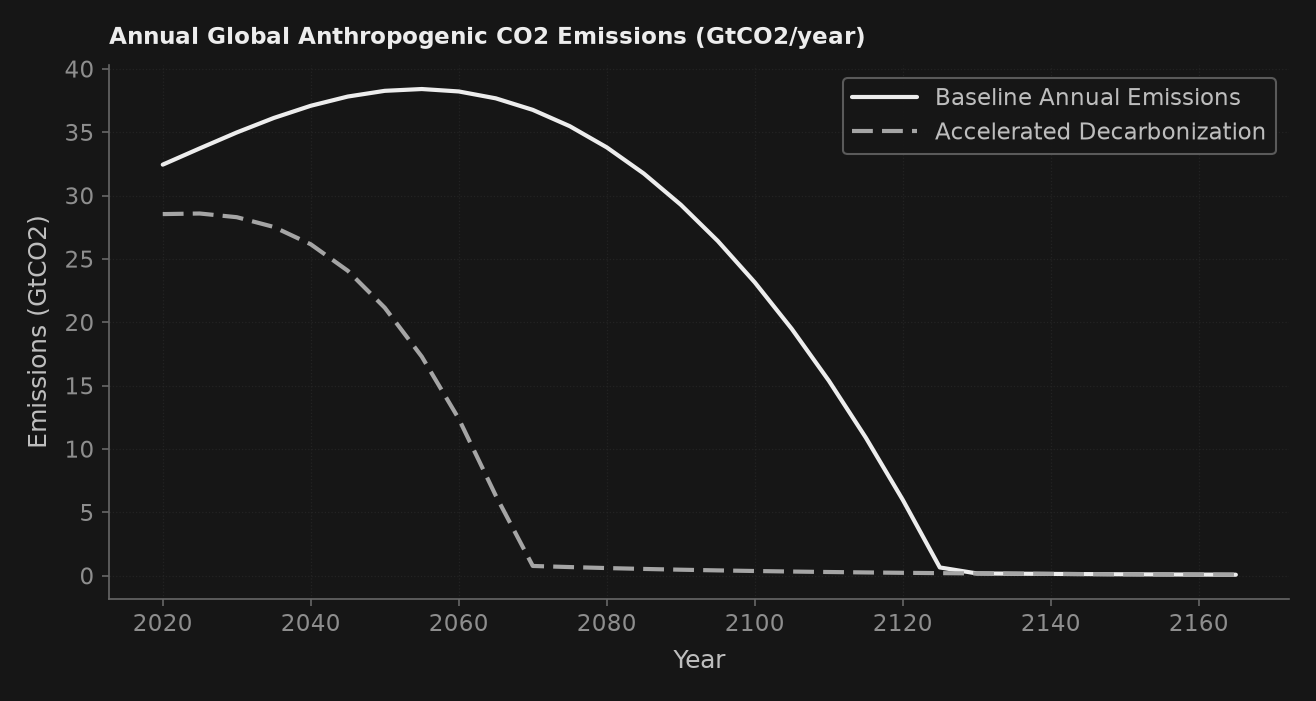

In [4]:
fig, ax = _nbstyle.figura(figsize=(8.5, 4.4))
ax.plot(res_base.trajectories.index, res_base.trajectories["emissions"], **_nbstyle.S1, label="Baseline Annual Emissions")
ax.plot(res_policy.trajectories.index, res_policy.trajectories["emissions"], **_nbstyle.S2, label="Accelerated Decarbonization")
ax.set_title("Annual Global Anthropogenic CO2 Emissions (GtCO2/year)", fontsize=11, fontweight="bold")
ax.set_xlabel("Year", color=_nbstyle.TEXTO)
ax.set_ylabel("Emissions (GtCO2)", color=_nbstyle.TEXTO)
ax.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

## 4. Macroeconomic Climate Damages (% of Gross World Product)

Economic damages in the DICE model reflect lost productive output due to environmental degradation:

$$ \text{Damages}_t = \Omega(T_{AT, t}) \, Y_{gross, t} $$

Under the Baseline trajectory, unabated warming extracts an escalating toll on global output: climate damages rise from $0.38\%$ of GDP in 2025 to $2.66\%$ by 2100 and exceed $4.2\%$ by 2150. In cumulative terms, this represents trillions of dollars of destroyed economic output annually.

Under the Accelerated Carbon Tax, although upfront abatement expenditures $\Lambda_t Y_{gross, t}$ are higher during the initial decades, damages are permanently capped below $1.1\%$ of GDP. The net social welfare gain—measured by the discounted utility integral $\sum_{t} \beta^t u(C_t)$—confirms that aggressive early carbon pricing generates substantial positive net economic returns.

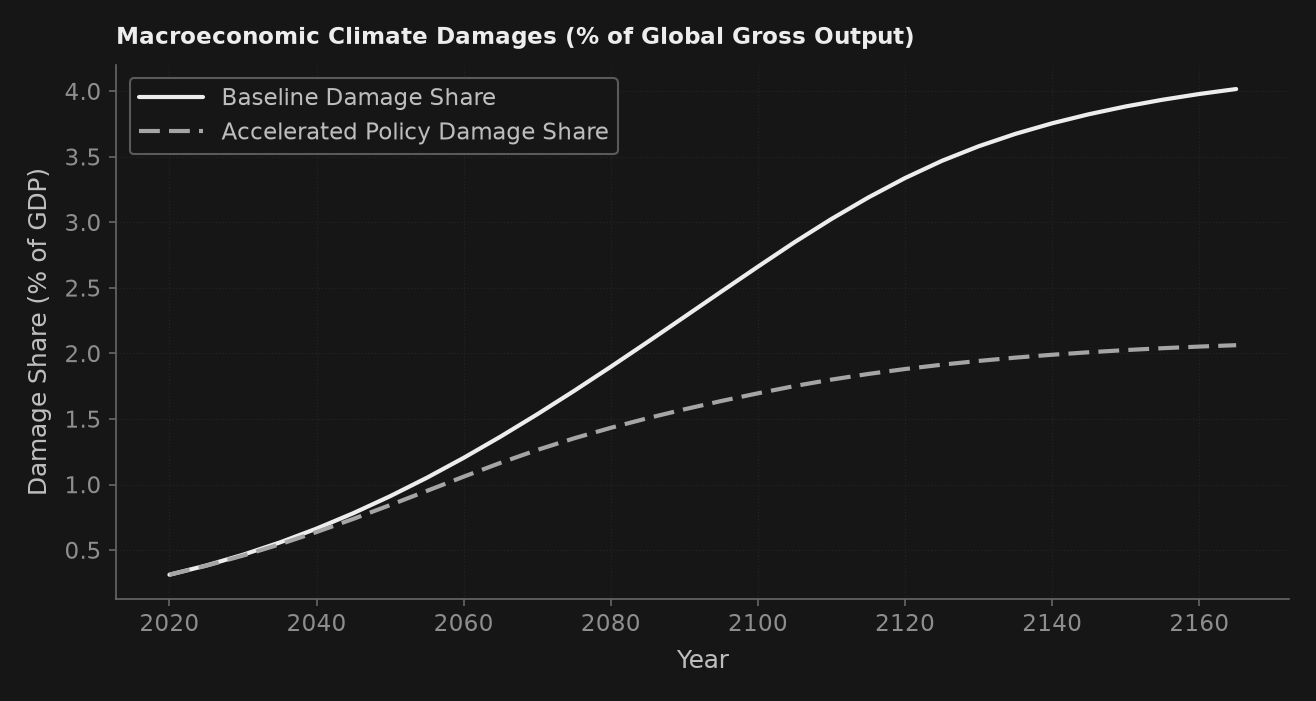

In [5]:
fig, ax = _nbstyle.figura(figsize=(8.5, 4.4))
ax.plot(res_base.trajectories.index, res_base.trajectories["damage_fraction"] * 100, **_nbstyle.S1, label="Baseline Damage Share")
ax.plot(res_policy.trajectories.index, res_policy.trajectories["damage_fraction"] * 100, **_nbstyle.S2, label="Accelerated Policy Damage Share")
ax.set_title("Macroeconomic Climate Damages (% of Global Gross Output)", fontsize=11, fontweight="bold")
ax.set_xlabel("Year", color=_nbstyle.TEXTO)
ax.set_ylabel("Damage Share (% of GDP)", color=_nbstyle.TEXTO)
ax.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)